In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)

print("pytorch:", torch.__version__)

pytorch: 2.12.1+cu130


In [2]:
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("loan_default_dataset.csv")
le = LabelEncoder()
df_clean = df.copy()

for col in ['Education', 'Loan_Purpose', 'Marital_Status']:
    df_clean[col] = le.fit_transform(df_clean[col])

df_clean['Loan_To_Income'] = df_clean['Loan_Amount'] / df_clean['Annual_Income']
df_clean['Risk_Score'] = (df_clean['Num_Late_Payments'] * 2 +
                           df_clean['Debt_To_Income_Ratio'] * 10 -
                           df_clean['Credit_Score'] / 100)

X = df_clean.drop(columns=['Loan_Default']).values.astype(np.float32)
y = df_clean['Loan_Default'].values.astype(np.int64)

X_mean = X.mean(axis=0)
X_std  = X.std(axis=0) + 1e-8
X = (X - X_mean) / X_std

print("X:", X.shape, "| y:", y.shape)

X: (5000, 15) | y: (5000,)


In [3]:
# same split as day 12
idx = np.random.permutation(len(X))
train_end = int(0.70 * len(X))
val_end   = int(0.85 * len(X))

X_train = torch.FloatTensor(X[idx[:train_end]])
y_train = torch.LongTensor(y[idx[:train_end]])
X_val   = torch.FloatTensor(X[idx[train_end:val_end]])
y_val   = torch.LongTensor(y[idx[train_end:val_end]])
X_test  = torch.FloatTensor(X[idx[val_end:]])
y_test  = torch.LongTensor(y[idx[val_end:]])

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val, y_val),     batch_size=64, shuffle=False)

print("train batches:", len(train_loader))
print("val batches  :", len(val_loader))

train batches: 55
val batches  : 12


In [4]:
# baseline MLP from day 11/12 (no regularization)

class BaselineMLP(nn.Module):
    def __init__(self, input_dim):
        super(BaselineMLP, self).__init__()
        self.fc1   = nn.Linear(input_dim, 64)
        self.relu1 = nn.ReLU()
        self.fc2   = nn.Linear(64, 32)
        self.relu2 = nn.ReLU()
        self.fc3   = nn.Linear(32, 2)

    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        return self.fc3(x)

baseline = BaselineMLP(X_train.shape[1])
print("baseline model:")
print(baseline)

baseline model:
BaselineMLP(
  (fc1): Linear(in_features=15, out_features=64, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=32, out_features=2, bias=True)
)


In [5]:
# RegularizedMLP — BatchNorm1d + Dropout added

class RegularizedMLP(nn.Module):
    def __init__(self, input_dim):
        super(RegularizedMLP, self).__init__()
        self.fc1   = nn.Linear(input_dim, 64)
        self.bn1   = nn.BatchNorm1d(64)    # normalizes across batch
        self.relu1 = nn.ReLU()
        self.drop1 = nn.Dropout(p=0.3)    # randomly zeros 30% neurons
        self.fc2   = nn.Linear(64, 32)
        self.bn2   = nn.BatchNorm1d(32)
        self.relu2 = nn.ReLU()
        self.drop2 = nn.Dropout(p=0.3)
        self.fc3   = nn.Linear(32, 2)

    def forward(self, x):
        x = self.drop1(self.relu1(self.bn1(self.fc1(x))))
        x = self.drop2(self.relu2(self.bn2(self.fc2(x))))
        return self.fc3(x)

reg_model = RegularizedMLP(X_train.shape[1])
print("regularized model:")
print(reg_model)

regularized model:
RegularizedMLP(
  (fc1): Linear(in_features=15, out_features=64, bias=True)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu1): ReLU()
  (drop1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu2): ReLU()
  (drop2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=32, out_features=2, bias=True)
)


In [6]:
# training function — works for both models

def train_model(model, train_loader, val_loader, epochs=30, lr=0.001):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        # training
        model.train()
        batch_losses = []
        for xb, yb in train_loader:
            optimizer.zero_grad()
            out  = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())

        # validation
        model.eval()
        val_batch_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                out  = model(xb)
                loss = criterion(out, yb)
                val_batch_losses.append(loss.item())

        train_losses.append(np.mean(batch_losses))
        val_losses.append(np.mean(val_batch_losses))

        print(f"epoch {epoch+1:02d}/30  train: {train_losses[-1]:.4f}  val: {val_losses[-1]:.4f}")

    return train_losses, val_losses

In [7]:
# train baseline model
print("--- training baseline MLP ---")
b_train_losses, b_val_losses = train_model(baseline, train_loader, val_loader, epochs=30)

--- training baseline MLP ---


epoch 01/30  train: 0.5262  val: 0.4603
epoch 02/30  train: 0.4909  val: 0.4500
epoch 03/30  train: 0.4841  val: 0.4465


epoch 04/30  train: 0.4821  val: 0.4465
epoch 05/30  train: 0.4795  val: 0.4453
epoch 06/30  train: 0.4763  val: 0.4439


epoch 07/30  train: 0.4771  val: 0.4435
epoch 08/30  train: 0.4728  val: 0.4419
epoch 09/30  train: 0.4707  val: 0.4422


epoch 10/30  train: 0.4680  val: 0.4440
epoch 11/30  train: 0.4662  val: 0.4455


...

epoch 19/30  train: 0.4417  val: 0.4425
epoch 20/30  train: 0.4371  val: 0.4484
epoch 21/30  train: 0.4375  val: 0.4503


epoch 22/30  train: 0.4315  val: 0.4451
epoch 23/30  train: 0.4287  val: 0.4468


epoch 24/30  train: 0.4236  val: 0.4491
epoch 25/30  train: 0.4197  val: 0.4492


epoch 26/30  train: 0.4180  val: 0.4527
epoch 27/30  train: 0.4152  val: 0.4610
epoch 28/30  train: 0.4115  val: 0.4598


epoch 29/30  train: 0.4080  val: 0.4595
epoch 30/30  train: 0.4060  val: 0.4585


In [8]:
# train regularized model
print("--- training regularized MLP ---")
r_train_losses, r_val_losses = train_model(reg_model, train_loader, val_loader, epochs=30)

--- training regularized MLP ---


epoch 01/30  train: 0.5858  val: 0.4917
epoch 02/30  train: 0.5091  val: 0.4652


epoch 03/30  train: 0.5038  val: 0.4606
epoch 04/30  train: 0.4966  val: 0.4578


epoch 05/30  train: 0.4950  val: 0.4589
epoch 06/30  train: 0.4896  val: 0.4527


epoch 07/30  train: 0.4872  val: 0.4526
epoch 08/30  train: 0.4894  val: 0.4572


...

epoch 21/30  train: 0.4782  val: 0.4461
epoch 22/30  train: 0.4719  val: 0.4449


epoch 23/30  train: 0.4746  val: 0.4449
epoch 24/30  train: 0.4720  val: 0.4448


epoch 25/30  train: 0.4712  val: 0.4455
epoch 26/30  train: 0.4697  val: 0.4461


epoch 27/30  train: 0.4740  val: 0.4464
epoch 28/30  train: 0.4673  val: 0.4467


epoch 29/30  train: 0.4726  val: 0.4479
epoch 30/30  train: 0.4747  val: 0.4473


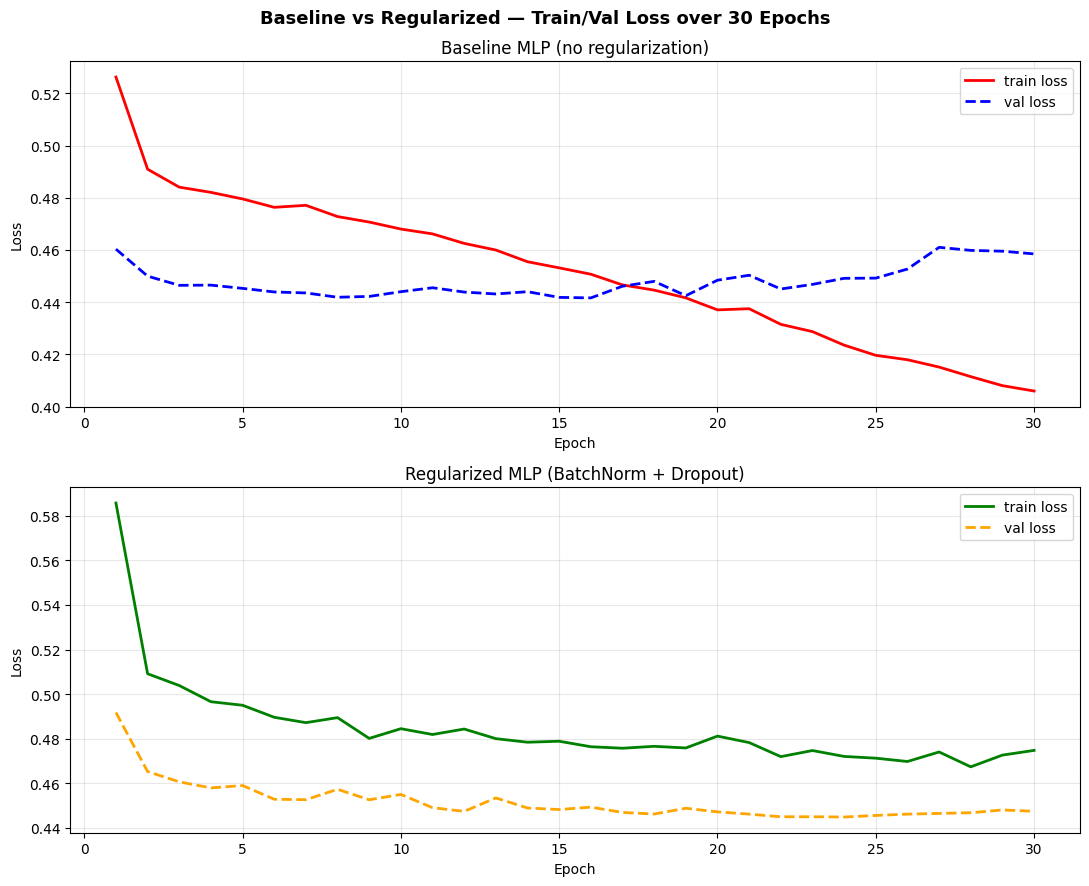

In [9]:
# 2x1 subplot comparing both models

fig, axes = plt.subplots(2, 1, figsize=(11, 9))
epochs_range = range(1, 31)

# baseline
axes[0].plot(epochs_range, b_train_losses, label='train loss', color='red',  linewidth=2)
axes[0].plot(epochs_range, b_val_losses,   label='val loss',   color='blue', linewidth=2, linestyle='--')
axes[0].set_title('Baseline MLP (no regularization)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# regularized
axes[1].plot(epochs_range, r_train_losses, label='train loss', color='green',  linewidth=2)
axes[1].plot(epochs_range, r_val_losses,   label='val loss',   color='orange', linewidth=2, linestyle='--')
axes[1].set_title('Regularized MLP (BatchNorm + Dropout)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Baseline vs Regularized — Train/Val Loss over 30 Epochs', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('regularization_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# final comparison
from sklearn.metrics import f1_score

def evaluate(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        out = model(X_test)
        _, preds = torch.max(out, 1)
        acc = (preds == y_test).float().mean().item()
        f1  = f1_score(y_test.numpy(), preds.numpy())
    return acc, f1

b_acc, b_f1 = evaluate(baseline,  X_test, y_test)
r_acc, r_f1 = evaluate(reg_model, X_test, y_test)

print("test results:")
print(f"baseline   -> acc: {b_acc*100:.2f}%  f1: {b_f1:.4f}")
print(f"regularized-> acc: {r_acc*100:.2f}%  f1: {r_f1:.4f}")

gap_b = abs(b_train_losses[-1] - b_val_losses[-1])
gap_r = abs(r_train_losses[-1] - r_val_losses[-1])
print()
print(f"train/val gap baseline   : {gap_b:.4f}")
print(f"train/val gap regularized: {gap_r:.4f}")
print("smaller gap = less overfitting")

test results:
baseline   -> acc: 79.60%  f1: 0.1547
regularized-> acc: 80.67%  f1: 0.0000

train/val gap baseline   : 0.0525
train/val gap regularized: 0.0274
smaller gap = less overfitting


In [11]:
# theory explanation
print("BatchNorm1d:")
print("  normalizes each feature across the batch")
print("  uses learnable gamma (scale) and beta (shift)")
print("  reduces internal covariate shift -> stable training")
print()
print("Dropout p=0.3:")
print("  randomly zeros 30% of neurons each forward pass")
print("  during training, retained activations scaled by 1/(1-p)")
print("  so x_hat = x * r / (1-p)  where r is 0 or 1")
print("  at eval time dropout is off, no scaling needed")
print("  acts like training many different sub-networks -> ensemble effect")
print()
print("model.train() -> dropout/batchnorm active")
print("model.eval()  -> dropout off, batchnorm uses running stats")

BatchNorm1d:
  normalizes each feature across the batch
  uses learnable gamma (scale) and beta (shift)
  reduces internal covariate shift -> stable training

Dropout p=0.3:
  randomly zeros 30% of neurons each forward pass
  during training, retained activations scaled by 1/(1-p)
  so x_hat = x * r / (1-p)  where r is 0 or 1
  at eval time dropout is off, no scaling needed
  acts like training many different sub-networks -> ensemble effect

model.train() -> dropout/batchnorm active
model.eval()  -> dropout off, batchnorm uses running stats
